# Projeto de Predição de Risco de AVC (Stroke Prediction)

## Introdução
Neste projeto será utilizado o dataset Stroke Prediction para desenvolver um modelo capaz de prever a ocorrência de Acidente Vascular Cerebral (AVC) a partir de características clínicas e demográficas dos pacientes.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

sns.set(style="whitegrid")
plt.rcParams["figure.figsize"] = (8,5)

df = pd.read_csv("healthcare-dataset-stroke-data.csv")

df.head()

,id,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
0,9046,Male,67.0,0,1,Yes,Private,Urban,228.69,36.6,formerly smoked,1
1,51676,Female,61.0,0,0,Yes,Self-employed,Rural,202.21,NaN,never smoked,1
2,31112,Male,80.0,0,1,Yes,Private,Rural,105.92,32.5,never smoked,1
3,60182,Female,49.0,0,0,Yes,Private,Urban,171.23,34.4,smokes,1
4,1665,Female,79.0,1,0,Yes,Self-employed,Rural,174.12,24.0,never smoked,1


# Visualização dos Dados

In [ ]:
print("="*60)
print("INFORMAÇÕES DO DATASET")
print("="*60)

display(df.head())

print("\nDimensões:", df.shape)

print("\nTipos das variáveis")
display(df.info())

print("\nEstatísticas descritivas")
display(df.describe())

print("\nValores nulos")
display(df.isnull().sum())

print("\nDuplicados:", df.duplicated().sum())

INFORMAÇÕES DO DATASET


,id,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
0,9046,Male,67.0,0,1,Yes,Private,Urban,228.69,36.6,formerly smoked,1
1,51676,Female,61.0,0,0,Yes,Self-employed,Rural,202.21,NaN,never smoked,1
2,31112,Male,80.0,0,1,Yes,Private,Rural,105.92,32.5,never smoked,1
3,60182,Female,49.0,0,0,Yes,Private,Urban,171.23,34.4,smokes,1
4,1665,Female,79.0,1,0,Yes,Self-employed,Rural,174.12,24.0,never smoked,1



Dimensões: (5110, 12)

Tipos das variáveis
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5110 entries, 0 to 5109
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   id                 5110 non-null   int64  
 1   gender             5110 non-null   object 
 2   age                5110 non-null   float64
 3   hypertension       5110 non-null   int64  
 4   heart_disease      5110 non-null   int64  
 5   ever_married       5110 non-null   object 
 6   work_type          5110 non-null   object 
 7   Residence_type     5110 non-null   object 
 8   avg_glucose_level  5110 non-null   float64
 9   bmi                4909 non-null   float64
 10  smoking_status     5110 non-null   object 
 11  stroke             5110 non-null   int64  
dtypes: float64(3), int64(4), object(5)
memory usage: 479.2+ KB


None


Estatísticas descritivas


,id,age,hypertension,heart_disease,avg_glucose_level,bmi,stroke
count,5110.000000,5110.000000,5110.000000,5110.000000,5110.000000,4909.000000,5110.000000
mean,36517.829354,43.226614,0.097456,0.054012,106.147677,28.893237,0.048728
std,21161.721625,22.612647,0.296607,0.226063,45.283560,7.854067,0.215320
min,67.000000,0.080000,0.000000,0.000000,55.120000,10.300000,0.000000
25%,17741.250000,25.000000,0.000000,0.000000,77.245000,23.500000,0.000000
50%,36932.000000,45.000000,0.000000,0.000000,91.885000,28.100000,0.000000
75%,54682.000000,61.000000,0.000000,0.000000,114.090000,33.100000,0.000000
max,72940.000000,82.000000,1.000000,1.000000,271.740000,97.600000,1.000000



Valores nulos


,0
id,0
gender,0
age,0
hypertension,0
heart_disease,0
ever_married,0
work_type,0
Residence_type,0
avg_glucose_level,0
bmi,201



Duplicados: 0


# Análise Exploratória de Dados (EDA)

## Gráfico 1 - Histograma da Idade

*   Item de lista
*   Item de lista



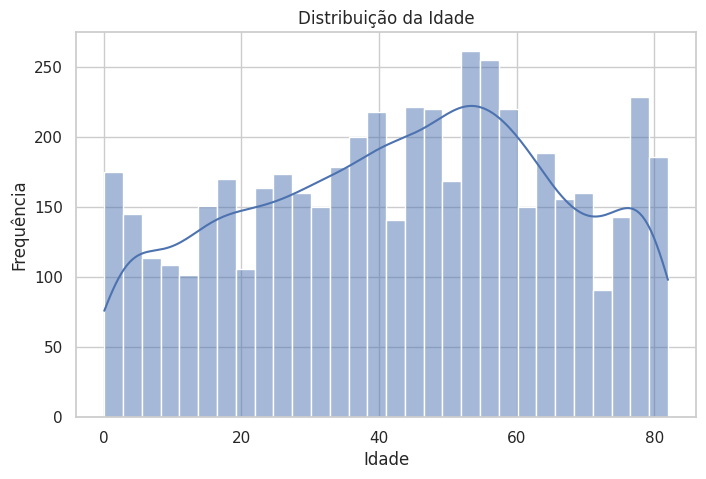

In [ ]:
plt.figure(figsize=(8,5))
sns.histplot(df["age"], bins=30, kde=True)
plt.title("Distribuição da Idade")
plt.xlabel("Idade")
plt.ylabel("Frequência")
plt.show()

### Observações sobre a Distribuição da Idade

O histograma mostra uma distribuição relativamente bem espalhada, mas com uma concentração visível em idades mais avançadas. Como o AVC é uma condição frequentemente associada ao envelhecimento, entender essa distribuição é vital. Observamos que o dataset cobre desde crianças até idosos, o que exigirá que o modelo identifique como o risco escala ao longo dos anos.

## Gráfico 2 - Boxplot do BMI

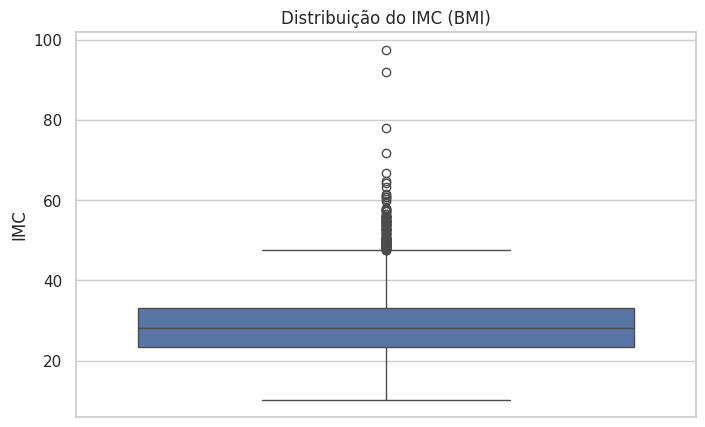

In [ ]:
plt.figure(figsize=(8,5))
sns.boxplot(y=df["bmi"])
plt.title("Distribuição do IMC (BMI)")
plt.ylabel("IMC")
plt.show()

### Observações sobre a Distribuição do IMC

O boxplot do IMC (BMI) revela uma grande quantidade de *outliers* na parte superior da escala (valores acima de 40-50). A mediana está em torno de 28, o que já indica sobrepeso segundo a OMS. Esses valores extremos são importantes, pois a obesidade é um fator de risco conhecido para doenças cardiovasculares.

## Gráfico 3 – Distribuição da variável alvo

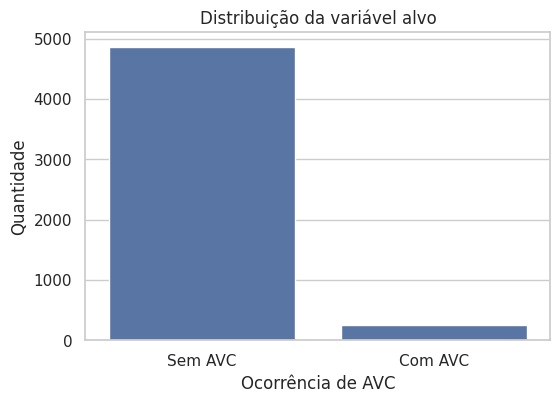

In [ ]:
plt.figure(figsize=(6,4))

ax = sns.countplot(data=df, x="stroke")
ax.set_xticks([0, 1])
ax.set_xticklabels(["Sem AVC", "Com AVC"])

plt.title("Distribuição da variável alvo")
plt.xlabel("Ocorrência de AVC")
plt.ylabel("Quantidade")

plt.show()

### Observações sobre a Distribuição da Variável Alvo

Identificamos um **desbalanceamento severo**: a vasta maioria dos casos é de 'Sem AVC'. Em problemas médicos, isso é comum, mas desafiador para o aprendizado de máquina. Se não tratado, o modelo pode simplesmente aprender a prever 'Sem AVC' para todos e ainda assim ter uma acurácia alta, por isso usaremos técnicas como `class_weight='balanced'`.

## Gráfico 4 – Heatmap de Correlação

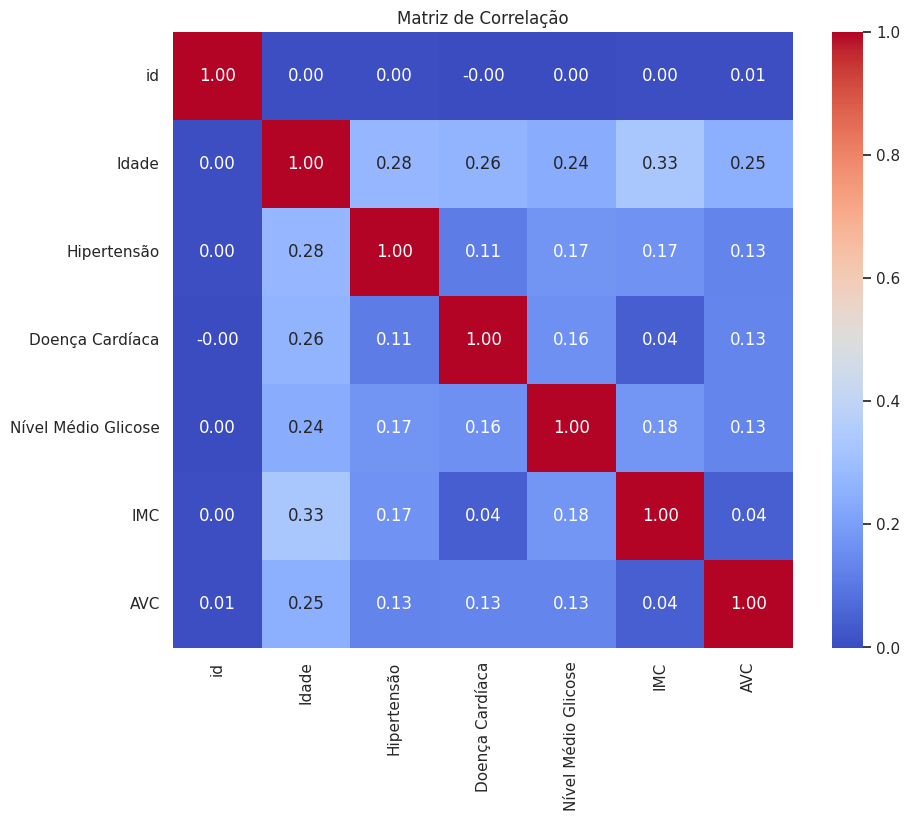

In [ ]:
plt.figure(figsize=(10,8))

# Selecionando colunas numéricas e renomeando para o gráfico
corr_data = df.select_dtypes(include=np.number).rename(columns={
    'age': 'Idade',
    'hypertension': 'Hipertensão',
    'heart_disease': 'Doença Cardíaca',
    'avg_glucose_level': 'Nível Médio Glicose',
    'bmi': 'IMC',
    'stroke': 'AVC'
})
corr = corr_data.corr()
sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Matriz de Correlação")
plt.show()

### Observações sobre a Correlação entre Variáveis Numéricas

A matriz de correlação mostra que a **Idade** é a variável com maior correlação positiva com o **AVC (stroke)** (0.25). Também notamos que Idade e Hipertensão/Doença Cardíaca andam juntas. O IMC, curiosamente, tem uma correlação linear baixa com o AVC diretamente, sugerindo que sua influência pode ser mediada por outros fatores ou não ser estritamente linear.

## Gráfico 5 - Idade por ocorrência de AVC

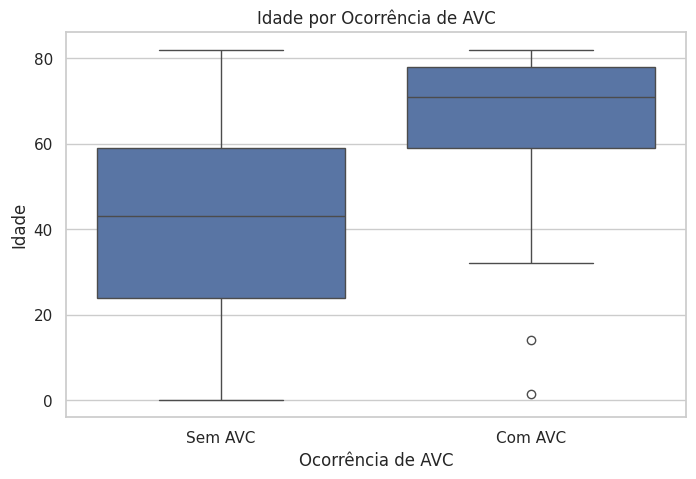

In [ ]:
plt.figure(figsize=(8,5))
sns.boxplot(data=df, x="stroke", y="age")
plt.title("Idade por Ocorrência de AVC")
plt.xlabel("Ocorrência de AVC")
plt.ylabel("Idade")
plt.xticks([0, 1], ["Sem AVC", "Com AVC"])
plt.show()

### Observações sobre Idade e AVC

Este boxplot comparativo é um dos mais reveladores: a distribuição de idade para quem sofreu AVC é muito mais alta e compacta (concentrada entre 60 e 80 anos). Para o grupo sem AVC, a distribuição é muito mais ampla. Isso confirma estatisticamente que a idade será provavelmente a *feature* mais importante para o nosso modelo preditivo.

# Pré-Processamento

### Etapas de Preparação dos Dados

Nesta fase, preparamos os dados para o modelo seguindo estas etapas:
1. **Remoção de Identificadores**: O `id` foi removido por não possuir valor preditivo.
2. **Tratamento de Dados Numéricos**: Utilizamos o `SimpleImputer` com a estratégia de mediana para preencher valores ausentes (como no IMC) e o `StandardScaler` para normalizar as grandezas, garantindo que variáveis com valores altos não dominem o modelo.
3. **Tratamento de Dados Categóricos**: Aplicamos o `OneHotEncoder` para transformar variáveis de texto em representações numéricas binárias.
4. **Pipeline e ColumnTransformer**: Integramos tudo em um fluxo automatizado para evitar erros de processamento e garantir que os mesmos critérios sejam aplicados nos dados de teste.

In [ ]:
df = df.drop(columns=["id"])

# Separar variáveis preditoras e variável alvo
X = df.drop("stroke", axis=1)
y = df["stroke"]

numeric_features = X.select_dtypes(include=["int64", "float64"]).columns.tolist()
categorical_features = X.select_dtypes(include=["object"]).columns.tolist()

print("Variáveis numéricas:", numeric_features)
print("Variáveis categóricas:", categorical_features)

# Pipeline para variáveis numéricas
numeric_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler())
    ]
)

# Pipeline para variáveis categóricas
categorical_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("encoder", OneHotEncoder(handle_unknown="ignore"))
    ]
)

# Pré-processamento completo
preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features)
    ]
)

# Divisão treino/teste
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("\nDimensões dos conjuntos:")
print(f"Treino: {X_train.shape}")
print(f"Teste : {X_test.shape}")

Variáveis numéricas: ['age', 'hypertension', 'heart_disease', 'avg_glucose_level', 'bmi']
Variáveis categóricas: ['gender', 'ever_married', 'work_type', 'Residence_type', 'smoking_status']

Dimensões dos conjuntos:
Treino: (4088, 10)
Teste : (1022, 10)


# Baseline (Regressão Logística)

### Por que a Regressão Logística?

Utilizamos a **Regressão Logística** como nosso modelo baseline por ser um algoritmo linear simples, rápido e de fácil interpretação.

O ponto crucial aqui é o uso do parâmetro `class_weight='balanced'`. Como vimos na EDA, há pouquíssimos casos de AVC no dataset. Sem esse ajuste, o modelo ignoraria a classe minoritária. Com o peso balanceado, o algoritmo penaliza mais fortemente o erro na classe 'Com AVC', buscando um melhor equilíbrio entre sensibilidade (Recall) e precisão.

BASELINE - REGRESSÃO LOGÍSTICA
Acurácia: 0.7456

Relatório de Classificação
              precision    recall  f1-score   support

           0       0.99      0.74      0.85       972
           1       0.14      0.80      0.24        50

    accuracy                           0.75      1022
   macro avg       0.56      0.77      0.54      1022
weighted avg       0.94      0.75      0.82      1022



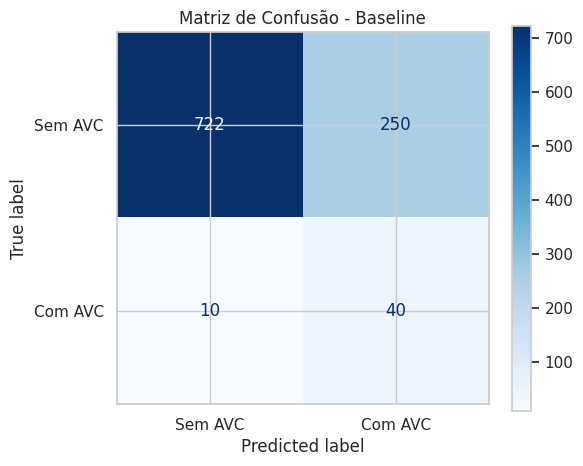

In [ ]:
baseline = Pipeline(
    steps=[
        ("preprocessamento", preprocessor),
        ("modelo", LogisticRegression(max_iter=1000, class_weight="balanced"))
    ]
)

# Treinamento
baseline.fit(X_train, y_train)

# Predições
y_pred = baseline.predict(X_test)

# Avaliação
accuracy = accuracy_score(y_test, y_pred)

print("=" * 70)
print("BASELINE - REGRESSÃO LOGÍSTICA")
print("=" * 70)

print(f"Acurácia: {accuracy:.4f}")

print("\nRelatório de Classificação")
print(classification_report(y_test, y_pred))

# Matriz de confusão
fig, ax = plt.subplots(figsize=(6,5))

ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred,
    display_labels=["Sem AVC", "Com AVC"],
    cmap="Blues",
    ax=ax
)

plt.title("Matriz de Confusão - Baseline")
plt.show()

# Conclusão

Neste projeto, foi desenvolvido um modelo de classificação para prever o risco de AVC. Os principais pontos observados foram:

1.  **Importância das Variáveis**: A análise exploratória confirmou que a **idade** é o fator de risco mais determinante, com a maioria dos casos de AVC concentrada em pacientes acima de 60 anos.
2.  **Desafio dos Dados**: O dataset é altamente desbalanceado (poucos casos positivos), o que exigiu o uso de técnicas como o `class_weight='balanced'` para que o modelo conseguisse identificar os casos de risco.
3.  **Desempenho do Modelo**: A Regressão Logística serviu como um excelente ponto de partida, alcançando um alto **Recall (80%)** na classe de risco. Isso significa que o modelo é eficaz em identificar a maioria dos pacientes que realmente podem sofrer um AVC, embora ainda gere alguns alarmes falsos (baixa precisão).